# OpenBind-HIPPO

- **Target: A71EV2A**
- **Cycle: 01**

## Imports

In [46]:
%load_ext autoreload
%autoreload 2
import hippo
import mrich
from mrich import print
from pathlib import Path
from os import environ
import shutil
import molparse as mp
import pandas as pd
import plotly.express as px
from mocassin.mocassin import calculate_mocassin_tversky
import parquet
from rdkit.Chem import PandasTools
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Config

In [2]:
target_name = "A71EV2A"
target_dir = Path(environ["BULK"]) / "TARGETS" / target_name
cycle_name = "cycle_01"
cycle_dir = Path(cycle_name)
aligned_dir = target_dir / "aligned_files"

## Animal

In [3]:
animal = hippo.HIPPO(target_name, target_dir / f"{target_name}.sqlite")

 Creating HIPPO animal

name = A71EV2A

db_path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite

DEBUG: hippo.Database.__init__()

DEBUG: Database.path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite

DEBUG: hippo.Database.connect()

DEBUG: sqlite3.version='2.6.0'

 Success  Database connected @ /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/A71EV2A/A71EV2A.sqlite!

 Success  Initialised animal HIPPO("A71EV2A")!

## Graveyard

In [ ]:
score_df = pd.read_csv(cycle_dir / "gnina" / "openbind_a71ev21_c1_scaffold_products_score.csv")
score_df.head()

In [ ]:
c = animal.db.execute("""
SELECT compound_id, pose_id, pose_reference
FROM pose
INNER JOIN compound
ON pose_compound = compound_id
""")

lookup = {}
for cid, pid, ref in c:
    lookup.setdefault(cid, {})
    lookup[cid].setdefault(ref, set())
    lookup[cid][ref].add(pid)

In [ ]:
def match_name(name):
    if name.startswith("P"):
        pose = getattr(animal, name)
        comp = pose.compound
    else:
        pose = animal.poses[name]
        comp = pose.compound
    
        if not name.startswith(f"C{comp.id}"):
            mrich.error(name, comp.id, pose.id)

        ref = int(name.split("-P")[-1])

        return list(lookup[comp.id][ref])[0], comp.id
    
    return pose.id, comp.id        

In [ ]:
for i,row in mrich.track(score_df.iterrows(), total=len(score_df)):
    pose_id, comp_id = match_name(row["name"])
    score_df.loc[i, "comp_id"] = comp_id
    score_df.loc[i, "pose_id"] = pose_id
score_df = score_df.reset_index()
score_df["comp_id"] = score_df["comp_id"].astype(int)
score_df["pose_id"] = score_df["pose_id"].astype(int)
score_df = score_df.set_index(["comp_id", "pose_id"])

In [ ]:
score_df.head()

In [ ]:
for (comp_id, pose_id),row in mrich.track(score_df.iterrows(), total=len(score_df)):
    pose = animal.poses[pose_id]
    metadata = dict(pose.metadata)
    metadata["GNINA pK"] = row["gnina_score"]
    pose.metadata.update(metadata)

In [ ]:
animal.db.backup()

In [ ]:
animal.load_sdf(
    target="A71EV2A",
    path="cycle_01/gnina/openbind_a71ev2a_c1_scaffold_products_minimized.sdf",
    pose_tags=["GNINA minimised"],
    name_col=None,
    # reference_col=None,
    # inspiration_col=None,
    energy_score_col="minimizedAffinity",
    distance_score_col="minimizedRMSD",
)

In [ ]:
animal.poses(tag="GNINA minimised").interactive()

In [ ]:
score_df["distance_score"] = [animal.poses[pose_id].distance_score for (comp_id, pose_id),_ in score_df.iterrows()]

In [ ]:
score_df["energy_score"] = [animal.poses[pose_id].energy_score for (comp_id, pose_id),_ in score_df.iterrows()]

In [ ]:
score_df["gnina_score_diff"] = score_df["gnina_score_min"] - score_df["gnina_score"]

In [ ]:
px.scatter(score_df, x="min_rmsd", y="gnina_score_diff")

In [ ]:
px.scatter(score_df, x="min_rmsd", y="distance_score")

In [ ]:
px.scatter(score_df, x="energy_score", y="gnina_score")

In [ ]:
mp = animal.poses(tag="GNINA minimised")[1]
print(mp)
mp.draw()
score_df[score_df.index.get_level_values(0) == mp.compound_id]

In [ ]:
for pose in animal.poses(tag="GNINA minimised"):
    print(pose)
    pose_ids = list(score_df[score_df.index.get_level_values(0) == pose.compound_id].index.get_level_values(1))
    pset = animal.poses[pose_ids]
    for p in pset:
        print(p.id, p.reference.id, p.inspirations.ids)
    break

In [ ]:
mdf = PandasTools.LoadSDF("cycle_01/gnina/openbind_a71ev2a_c1_scaffold_products_minimized_orig.sdf")

In [ ]:
# from rdkit.Chem import PandasTools
sdf = PandasTools.LoadSDF("cycle_01/bulkdock/openbind_a71ev2a_c1_scaffold_products.sdf")
sdf = sdf.set_index("ID")

In [ ]:
for i,row in mdf.iterrows():
    try:
        match = sdf.loc[row["ID"]]
    except KeyError:
        mrich.error(i)
        continue
    mdf.loc[i, "ref_mols"] = match["ref_mols"]
    mdf.loc[i, "ref_pdb"] = match["ref_pdb"]

In [ ]:
PandasTools.WriteSDF(mdf, "cycle_01/gnina/openbind_a71ev2a_c1_scaffold_products_minimized.sdf", properties=mdf.columns)

In [ ]:
score_df[score_df.index.get_level_values(1) == 810]

In [ ]:
score_df[score_df["name"] == "C33321-P170"]

In [ ]:
mp.compound.draw()

In [ ]:
animal.P810.compound.draw()

In [ ]:
mp.compound.smiles

In [ ]:
animal.db.query_similarity('O=S(=O)(C1CCCN(c2ncco2)C1)N1CCc2ccccc21', 0.9).ids

In [ ]:
pset = animal.C33321.poses
print(animal.db.get_pose_tag_dict(pset))
pset

In [ ]:
score_df[(score_df.index.get_level_values(0) > 33300) & (score_df.index.get_level_values(0) < 33452)]

In [ ]:
match_name("C33321-P170")

In [ ]:
animal.poses["C33321-P170"]

In [ ]:
animal.P123821.summary()

In [ ]:
c = animal.db.execute("""
SELECT pose_id FROM pose
WHERE pose_alias LIKE 'C%-P%'
""")

pset = animal.poses[[i for i, in c]]
pset

In [ ]:
mol_block = """
     RDKit          3D

 27 28  0  0  0  0  0  0  0  0999 V2000
    7.0381   10.3908   25.8630 O   0  0  0  0  0  0  0  0  0  0  0  0
    7.8008   10.8530   25.0216 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.5970    9.9524   24.1295 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.7349   10.5535   23.3501 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.9206   12.0573   23.4739 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.6138   12.7964   23.7398 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.8591   14.3007   23.9581 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.1050   14.9406   22.7137 O   0  0  0  0  0  0  0  0  0  0  0  0
   10.3906   15.1247   22.3568 C   0  0  0  0  0  0  0  0  0  0  0  0
   10.8366   15.3382   21.0406 C   0  0  0  0  0  0  0  0  0  0  0  0
   12.1571   15.5066   20.9876 N   0  0  0  0  0  0  0  0  0  0  0  0
   12.5415   15.4569   22.2676 N   0  0  0  0  0  0  0  0  0  0  0  0
   11.5188   15.1971   23.1397 C   0  0  0  0  0  0  0  0  0  0  0  0
    7.9427   12.1974   24.8779 N   0  0  0  0  0  0  0  0  0  0  0  0
    7.9218    9.4633   23.4420 H   0  0  0  0  0  0  0  0  0  0  0  0
    8.9784    9.1425   24.7403 H   0  0  0  0  0  0  0  0  0  0  0  0
    9.6254   10.2836   22.2984 H   0  0  0  0  0  0  0  0  0  0  0  0
   10.6417   10.0311   23.6522 H   0  0  0  0  0  0  0  0  0  0  0  0
   10.6217   12.2750   24.2860 H   0  0  0  0  0  0  0  0  0  0  0  0
   10.3981   12.4210   22.5600 H   0  0  0  0  0  0  0  0  0  0  0  0
    7.9505   12.6676   22.8781 H   0  0  0  0  0  0  0  0  0  0  0  0
    7.9378   14.7527   24.3466 H   0  0  0  0  0  0  0  0  0  0  0  0
    9.6190   14.4920   24.7244 H   0  0  0  0  0  0  0  0  0  0  0  0
   10.2614   15.3763   20.1242 H   0  0  0  0  0  0  0  0  0  0  0  0
   13.5263   15.6091   22.4586 H   0  0  0  0  0  0  0  0  0  0  0  0
   11.6995   15.1356   24.1998 H   0  0  0  0  0  0  0  0  0  0  0  0
    7.2173   12.7208   25.3586 H   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  2  0
  2  3  1  0
  3  4  1  0
  4  5  1  0
  5  6  1  0
  6  7  1  0
  7  8  1  0
  8  9  1  0
  9 10  1  0
 10 11  2  0
 11 12  1  0
 12 13  1  0
  6 14  1  0
 14  2  1  0
 13  9  2  0
  3 15  1  0
  3 16  1  0
  4 17  1  0
  4 18  1  0
  5 19  1  0
  5 20  1  0
  6 21  1  0
  7 22  1  0
  7 23  1  0
 10 24  1  0
 12 25  1  0
 13 26  1  0
 14 27  1  0
M  END
"""

In [ ]:
from rdkit import Chem

In [ ]:
Chem.MolFromMolBlock(mol_block)

In [ ]:
animal.C33321.draw()

In [ ]:
animal.C62872.draw()

In [ ]:
animal.P123821.smiles

In [ ]:
from hippo.tools import sanitise_smiles

In [ ]:
sanitise_smiles("O=C1CCC[C@H](COc2cn[nH]c2)N1")

In [ ]:
animal.compounds(smiles="O=C1CCC[C@H](COc2cn[nH]c2)N1")

In [ ]:
lookup = animal.db.get_compound_id_smiles_dict()
lookup = {v:k for k,v in lookup.items()}

In [ ]:
c = animal.db.execute(
# """
# SELECT pose_id, pose_compound, pose_smiles, mol_to_smiles(mol_from_binary_mol(pose_mol)) 
# FROM pose 
# WHERE pose_id IN (646,647)
# """

"""
SELECT pose_id, pose_compound, pose_smiles 
FROM pose 
"""
)
records = c.fetchall()
len(records)

In [ ]:
fixes = []

for pid, c1, s1 in mrich.track(records):
    # print(pid, c1, s1)

    # if s1 != s2:
    #     mrich.error(pid, "SMILES MISMATCH")

    try:
        flat = sanitise_smiles(s1)
    except:
        mrich.error("Sanitisation error", pid, s1)
        continue

    c2 = lookup.get(flat)

    if not c2:
        continue

    if c1 != c2:
        # mrich.error(pid, "COMPOUND MISMATCH")
        fixes.append((pid, c2, s2))

In [ ]:
len(fixes)

In [ ]:
fixes[0]

In [ ]:
sql = """
UPDATE pose
SET pose_compound = ?2
WHERE pose_id = ?1
"""

animal.db.executemany(sql, [(a,b) for a,b,c in fixes])
animal.db.commit()

In [ ]:
p = animal.P646

print(p.id)
print(p.compound_id)
print(p.smiles)
print(p.compound.smiles)
p.draw()
p.compound.draw()

In [ ]:
import re
import numpy as np
from molparse.rdkit import mol_from_smiles
from rdkit.Chem.inchi import MolToInchiKey
from rdkit.Chem import MolFromSmiles, MolToSmiles, AddHs, RemoveHs
import mcol
from datetime import datetime
from string import ascii_uppercase

import mrich


def smiles_has_isotope(smiles, regex=True):
    """

    :param smiles:
    :param regex:  (Default value = True)

    """
    if regex:
        return re.search(r"([\[][0-9]+[A-Z]+\])", smiles)
    else:
        mol = MolFromSmiles(smiles)
        return any(atom.GetIsotope() for atom in mol.GetAtoms())

def sanitise_smiles(s, verbosity=False, sanitisation_failed="error", radical="error"):
    """

    :param s:
    :param verbosity:  (Default value = False)
    :param sanitisation_failed:  (Default value = 'error')
    :param radical:  (Default value = 'error')

    """

    assert isinstance(s, str), f"non-string smiles={s}"

    orig_smiles = s

    # if multiple molecules take the largest
    if "." in s:
        s = sorted(s.split("."), key=lambda x: len(x))[-1]

    # flatten the smiles
    stereo_smiles = s
    smiles = s.replace("@", "")
    smiles = smiles.replace("/", "")
    smiles = smiles.replace("\\", "")

    # remove isotopic stuff
    if smiles_has_isotope(smiles):
        mrich.warning(f"Isotope(s) in SMILES: {smiles}")
        smiles = remove_isotopes_from_smiles(smiles)

    # canonicalise
    mol = MolFromSmiles(smiles)
    if mol:
        smiles = MolToSmiles(mol, True)
    elif sanitisation_failed == "error":
        raise SanitisationError
    elif sanitisation_failed == "warning":
        mrich.warning(f"sanitisation failed for {smiles=}")

    # check radicals
    reconstruct = False
    for atom in mol.GetAtoms():
        if not atom.GetNumRadicalElectrons():
            continue

        if radical == "warning":
            mrich.warning(f"Radical atom in {smiles=}")
        elif radical == "error":
            raise SanitisationError(f"Radical atom in {smiles=}")
        elif radical == "remove":
            mrich.warning(f"Removed radical atom")
            atom.SetNumRadicalElectrons(0)
            smiles = MolToSmiles(mol, True)
            reconstruct = True
            # atom.SetFormalCharge(0)
        else:
            raise NotImplementedError(f"Unknown option {radical=}")

    if reconstruct:
        mol = AddHs(mol)
        mol = RemoveHs(mol, implicitOnly=True)
        smiles = MolToSmiles(mol, True)
        mrich.warning(f"New {smiles=}")

    if verbosity:

        if smiles != orig_smiles:

            annotated_smiles_str = orig_smiles.replace(
                ".", f"{mcol.error}{mcol.underline}.{mcol.clear}{mcol.warning}"
            )
            annotated_smiles_str = annotated_smiles_str.replace(
                "@", f"{mcol.error}{mcol.underline}@{mcol.clear}{mcol.warning}"
            )

            mrich.warning(f"SMILES was changed: {annotated_smiles_str} --> {smiles}")

    return smiles

In [ ]:
sanitise_smiles("CCC[S@OH](=O)(=O)Nc1cccc(C(=O)NCCc2ccon2)c1")

In [ ]:
%autoreload 2
from posecheck import PoseCheck

## Load Openfold Parquet

In [ ]:
import pyarrow.parquet as pq

In [ ]:
table = pq.read_table("cycle_01/openfold/A71EV2A_enumerations_cofolding_utility_20251027.parquet")

In [ ]:
df = table.to_pandas()

In [ ]:
df

## Load combined BB quote

In [ ]:
# clear existing quotes
animal.db.backup()
animal.db.execute("DELETE FROM quote")
animal.db.commit()

In [64]:
q = animal.add_enamine_quote(
    "../combined/Q2135669_2025-11(nov)-14-OpenBind-buildingblocks-c1(chempspace).xlsx",
    orig_name_col = "HIPPO Compound ID (a71ev2a)",
    smiles_col = "quoted_smiles",
    entry_col = "quote_entry",
    fixed_amount = 1,
    price_col = "quote-1mg",
    fixed_purity = None,
    fixed_lead_time = None,
    dry_run = False,
    currency = "EUR",
    allow_no_catalogue_col = True,
    orig_name_is_hippo_id=True,
    warn_nan_orig_name = False,
    overwrite_existing_quotes=False,
    delete_unavailable = False,
    debug = False,
)
q

Output()

 Warning  SMILES changed during compound registration: c1cc(C2CCNC2)[nH]n1 --> c1cc(C2CCNC2)n[nH]1!

{Ingredient × 293}

In [65]:
q = animal.add_enamine_quote(
    "../combined/Q2135669_2025-11(nov)-14-OpenBind-buildingblocks-c1(chempspace).xlsx",
    orig_name_col = "HIPPO Compound ID (a71ev2a)",
    smiles_col = "quoted_smiles",
    entry_col = "quote_entry",
    fixed_amount = 10,
    price_col = "quote-10mg",
    fixed_purity = None,
    fixed_lead_time = None,
    dry_run = False,
    currency = "EUR",
    allow_no_catalogue_col = True,
    orig_name_is_hippo_id=True,
    warn_nan_orig_name = False,
    overwrite_existing_quotes=False,
    delete_unavailable = False,
    debug = False,
)
q

Output()

 Warning  SMILES changed during compound registration: c1cc(C2CCNC2)[nH]n1 --> c1cc(C2CCNC2)n[nH]1!

{Ingredient × 293}

## Revisit GNINA scores

In [22]:
ref_sdf = "cycle_01/syndirella/elabs/openbind_a71ev2a_c1_elab_chemspace_filtered.sdf"
pdf = PandasTools.LoadSDF(ref_sdf)
pdf = pdf[["HIPPO Pose ID", "ID"]].rename(columns={"HIPPO Pose ID":"id", "ID":"name"}).iloc[1:].set_index("name")
pdf.head()

,id
name,
P5840,5840
P12401,12401
P20859,20859
P21244,21244
P23665,23665


In [15]:
sdf = pd.read_csv("cycle_01/gnina/openbind_a71ev2a_c1_elab_chemspace_filtered_scores.csv")
sdf.head()

,name,gnina_score,gnina_score_min,smina_score_min,min_rmsd
0,P5840,4.919,4.986,-6.092,0.940
1,P12401,5.019,5.118,19.537,0.474
2,P20859,3.989,4.061,16.739,1.006
3,P21244,2.504,3.020,61.806,2.903
4,P23665,3.992,5.234,5.447,5.818


In [27]:
sdf["pose_id"] = sdf["name"].apply(lambda x: int(pdf.loc[x, "id"]))
sdf = sdf.set_index("pose_id")
sdf

,name,gnina_score,gnina_score_min,smina_score_min,min_rmsd
pose_id,,,,,
5840,P5840,4.919,4.986,-6.092,0.940
12401,P12401,5.019,5.118,19.537,0.474
20859,P20859,3.989,4.061,16.739,1.006
21244,P21244,2.504,3.020,61.806,2.903
23665,P23665,3.992,5.234,5.447,5.818
...,...,...,...,...,...
534254,IWRSJYUNVXHDNX-UHFFFAOYSA-N-P248-P135-P248-601519,2.564,5.023,8.169,3.436
534256,NXPYRYGQBYSGQH-UHFFFAOYSA-N-P248-P135-P248-601519,3.083,4.907,2.775,3.938
534258,JOHUJKPJURWJPF-UHFFFAOYSA-N-P248-P135-P248-601519,3.021,4.909,6.657,4.126


In [30]:
pose_ids = set()
for i,row in sdf.iterrows():
    pose = animal.poses[i]
    metadata = pose.metadata
    metadata.update({
        "gnina_score":row["gnina_score"],
        "gnina_score_min":row["gnina_score_min"],
        "smina_score_min":row["smina_score_min"],
        "rmsd(smina/fragmenstein)":row["min_rmsd"],
    })
    pose_ids.add(i)
    # break
scored_poses = animal.poses[pose_ids]
scored_poses.add_tag("openbind_a71ev2a_c1_elab_chemspace_filtered_scored")

Tagged {P × 2095} w/ "openbind_a71ev2a_c1_elab_chemspace_filtered_scored"

## GNINA score distributions

In [31]:
scored_poses = animal.poses(tag="openbind_a71ev2a_c1_elab_chemspace_filtered_scored")
scored_poses

poses tagged "openbind_a71ev2a_c1_elab_chemspace_filtered_scored": {P × 2095}

In [35]:
data = []
for pose in scored_poses:
    metadata = pose.metadata
    data.append({
        "pose_id":pose.id, 
        "gnina_score":metadata["gnina_score"],
        "gnina_score_min":metadata["gnina_score_min"],
        "smina_score_min":metadata["smina_score_min"],
        "rmsd(smina/fragmenstein)":metadata["rmsd(smina/fragmenstein)"],
    })
df = pd.DataFrame(data)

In [38]:
score_cutoff = df["gnina_score_min"].quantile(0.20)
score_cutoff

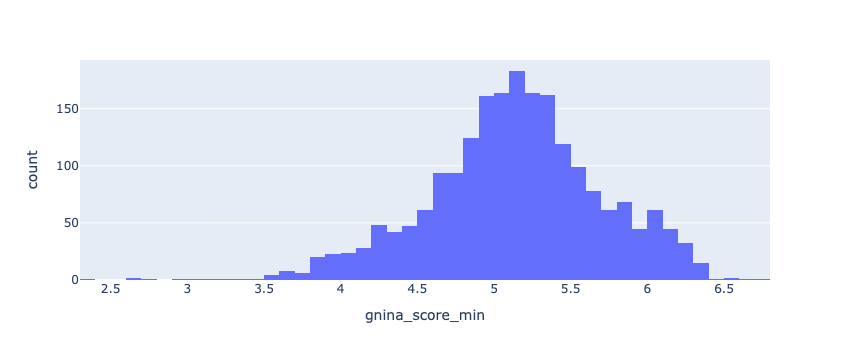

In [36]:
px.histogram(df, x="gnina_score_min")

In [44]:
filtered_scored_ids = df[df["gnina_score_min"] >= score_cutoff]["pose_id"].unique()

In [53]:
filtered_scored_poses = animal.poses[filtered_scored_ids]
filtered_scored_poses

{P × 1677}

In [54]:
filtered_scored_poses.compounds

{C × 1677}

## What is the cost of the filtered compounds?

In [66]:
%%time
recipe = hippo.Recipe.from_compounds(
    filtered_scored_poses.compounds, 
    pick_cheapest=True,
    quoted_only=True,
    use_routes=False,
)
recipe

#compounds = 1677

Output()

 ERROR  Reactants not available for reaction=R1611: C286014 + C286015 -> C1373 via Amidation!

 ERROR  No solutions for compound=C1373 (comp.reactions.ids=[1611])!

 ERROR  Reactants not available for reaction=R1553: C285933 + C285934 -> C1613 via Amidation!

...

Picking cheapest from 1 options

DEBUG: No quote available for C292524 with amount >= 105.0 mg. Estimating price...

CPU times: user 1min 48s, sys: 1min 7s, total: 2min 55s

Wall time: 18min 12s

Recipe({Ingredient × 202} --> {Ingredient × 228} via {R × 228})

In [67]:
recipe.write_json("cycle_01/gnina/openbind_a71ev2a_c1_elab_chemspace_filtered_scored_top80percent_recipe.json")

DEBUG: No quote available for C292524 with amount >= 105.0 mg. Estimating price...

 DISK  Writing 
/opt/xchem-fragalysis-2/maxwin/openbind-hippo/a71ev2a/cycle_01/gnina/openbind_a71ev2a_c1_elab_chemspace_filtered_sc
ored_top80percent_recipe.json...

In [68]:
recipe.write_reactant_csv("cycle_01/gnina/openbind_a71ev2a_c1_elab_chemspace_filtered_scored_top80percent_reactants.csv")

DEBUG: Querying database for routes

DEBUG: Assembling route dictionary

DEBUG: Checking availability

DEBUG: No quote available for C292524 with amount >= 105.0 mg. Estimating price...

 DISK  Writing cycle_01/gnina/openbind_a71ev2a_c1_elab_chemspace_filtered_scored_top80percent_reactants.csv...

In [69]:
recipe.write_CAR_csv("cycle_01/gnina/openbind_a71ev2a_c1_elab_chemspace_filtered_scored_top80percent_CAR.csv")

DEBUG: Querying database for routes

DEBUG: Assembling route dictionary

DEBUG: Checking availability

Output()

 DISK  Writing 
/opt/xchem-fragalysis-2/maxwin/openbind-hippo/a71ev2a/cycle_01/gnina/openbind_a71ev2a_c1_elab_chemspace_filtered_sc
ored_top80percent_CAR_1steps.csv...

 DISK  Writing 
/opt/xchem-fragalysis-2/maxwin/openbind-hippo/a71ev2a/cycle_01/gnina/openbind_a71ev2a_c1_elab_chemspace_filtered_sc
ored_top80percent_CAR.csv...

,target-names,no-steps,concentration-required-mM,amount-required-uL,batch-tag,reactant-1-1,reactant-2-1,reaction-product-smiles-1,reaction-name-1,reaction-recipe-1,reaction-groupby-column-1
0,C290556,1,None,None,None,O=C(O)C1CCN2CCCCC2C1,CN1CC(N)C1c1ccccc1,CN1CC(NC(=O)C2CCN3CCCCC3C2)C1c1ccccc1,Amidation,None,None
1,C292583,1,None,None,None,CC(CO)CNN,COC(=O)c1cc(C2CC2)ncc1Br,COC(=O)c1cc(C2CC2)ncc1N(N)CC(C)CO,N-nucleophilic_aromatic_substitution,None,None
2,C290570,1,None,None,None,O=C(O)CCCN1CCCCC1=O,COc1cc(C2CCN2)ccc1Br,COc1cc(C2CCN2C(=O)CCCN2CCCCC2=O)ccc1Br,Amidation,None,None
3,C292585,1,None,None,None,CCC(O)CNN,COC(=O)c1cc(C2CC2)ncc1Br,CCC(O)CN(N)c1cnc(C2CC2)cc1C(=O)OC,N-nucleophilic_aromatic_substitution,None,None
4,C291534,1,None,None,None,CC(Sc1ccc(Br)c(Br)n1)C(=O)O,COCC12CCC(CC1)N2,COCC12CCC(CC1)N2C(=O)C(C)Sc1ccc(Br)c(Br)n1,Amidation,None,None
...,...,...,...,...,...,...,...,...,...,...,...
223,C291191,1,None,None,None,O=C(O)c1ccnc(SCc2ccccc2)c1,CC(N)C1CCO1,CC(NC(=O)c1ccnc(SCc2ccccc2)c1)C1CCO1,Amidation,None,None
224,C290537,1,None,None,None,O=C(O)C1CC(=O)N2CCCCC2C1,Cc1ccc(C2CCN2)cc1,Cc1ccc(C2CCN2C(=O)C2CC(=O)N3CCCCC3C2)cc1,Amidation,None,None
225,C290543,1,None,None,None,O=C(O)C1CCN2CCCCC2C1,Cc1cccc(C2NCC2C)c1,Cc1cccc(C2C(C)CN2C(=O)C2CCN3CCCCC3C2)c1,Amidation,None,None
226,C290544,1,None,None,None,O=C(O)C1CCN2CCCCC2C1,Cc1cccc(C)c1C1CCN1,Cc1cccc(C)c1C1CCN1C(=O)C1CCN2CCCCC2C1,Amidation,None,None


In [70]:
recipe.price

DEBUG: No quote available for C292524 with amount >= 105.0 mg. Estimating price...

€8335.00 EUR

## Recipe Scoring

In [ ]:
scorer = hippo.Scorer.default(
    animal.db, 
    "cycle_01/rgen/a71ev2a_c1_elabs_recipes",
    load_cache=False,
    out_key="scorer_elabs",
    skip=[
        "elaboration_balance",
        "num_scaffolds_elaborated",
        "num_inspirations",
        "interaction_balance",
        "avg_distance_score",
        "avg_energy_score",
        "subsite_balance",
        "num_subsites",
        "num_scaffolds",
    ],
)

In [ ]:
scorer.attributes

In [ ]:
scorer.summary()

In [ ]:
scorer.plot(["price","num_compounds"])

In [4]:
animal.tags.summary()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ tag                                         ┃ num_compounds ┃ num_poses ┃ num_posed_compounds ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ BAD count                                   │ 0             │ 645       │ 457                 │
│ BulkDock Fragalysis export                  │ 0             │ 31407     │ 30761               │
│ C10 85percent analogue                      │ 31            │ 0         │ 0                   │
│ C10 90percent analogue                      │ 6             │ 0         │ 0                   │
│ C10 95percent analogue                      │ 1             │ 0         │ 0                   │
│ C100 85percent analogue                     │ 32            │ 0         │ 0                   │
│ C100 90percent analogue                     │ 8             │ 0         │ 0                   │
│ C100 95percent analogue                     │ 3             │ 0         │ 0                   │
│ C101 85percent analogue                     │ 2             │ 0         │ 0                   │
│ C102 85percent analogue                     │ 5             │ 0         │ 0                   │
│ C102 90percent analogue                     │ 2             │ 0         │ 0                   │
│ C103 85percent analogue                     │ 3             │ 0         │ 0                   │
│ C104 85percent analogue                     │ 19            │ 0         │ 0                   │
│ C104 90percent analogue                     │ 6             │ 0         │ 0                   │
│ C105 85percent analogue                     │ 32            │ 0         │ 0                   │
│ C105 90percent analogue                     │ 6             │ 0         │ 0                   │
│ C106 85percent analogue                     │ 24            │ 0         │ 0                   │
│ C106 90percent analogue                     │ 2             │ 0         │ 0                   │
│ C107 85percent analogue                     │ 2             │ 0         │ 0                   │
│ C108 85percent analogue                     │ 3             │ 0         │ 0                   │
│ C108 90percent analogue                     │ 2             │ 0         │ 0                   │
│ C109 85percent analogue                     │ 108           │ 0         │ 0                   │
│ C109 90percent analogue                     │ 3             │ 0         │ 0                   │
│ C11 85percent analogue                      │ 11            │ 0         │ 0                   │
│ C11 90percent analogue                      │ 4             │ 0         │ 0                   │
│ C11 95percent analogue                      │ 3             │ 0         │ 0                   │
│ C111 85percent analogue                     │ 15            │ 0         │ 0                   │
│ C111 90percent analogue                     │ 1             │ 0         │ 0                   │
│ C112 85percent analogue                     │ 7             │ 0         │ 0                   │
│ C113 85percent analogue                     │ 4             │ 0         │ 0                   │
│ C113 90percent analogue                     │ 1             │ 0         │ 0                   │
│ C114 85percent analogue                     │ 7             │ 0         │ 0                   │
│ C114 90percent analogue                     │ 2             │ 0         │ 0                   │
│ C115 85percent analogue                     │ 129           │ 0         │ 0                   │
│ C115 90percent analogue                     │ 8             │ 0         │ 0                   │
│ C116 85percent analogue                     │ 3             │ 0         │ 0                   │
│ C117 85percent analogue                     │ 5             │ 0         │ 0                   │
│ C117 90percent analogue                     │ 1             │ 0         │ 0   